# Multi-Case Sizing

Notes on why single-condition sizing is non-conservative for flight envelopes and how the multi-case NLP fixes it — follows `demo_multicase_sizing.py`.

- Part A: conceptual bending-dominated vs pressure-dominated load pair
- Part B: real flight envelope from `scripts/flight_envelope.csv`
- Governing case per ply at root, mid, and tip span stations

In [1]:
import sys, os
from pathlib import Path

# Resolve repo root regardless of where Jupyter was launched from
_nb_dir = Path(os.path.abspath("")).resolve()
_repo_root = _nb_dir.parent if _nb_dir.name == "notebooks" else _nb_dir
sys.path.insert(0, str(_repo_root / "src"))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from composite_panel import IM7_8552, LoadCase, LoadsDatabase, Ply, Laminate
from composite_panel import check_laminate
from composite_panel.optimizer import (
    optimize_laminate, optimize_laminate_multicase,
    detect_balance_pairs,
)

---
## 1. Material and Laminate Family

We use IM7/8552 with the balanced quasi-isotropic half-stack `[0, 45, -45, 90]`. Detecting **balance pairs** (angle-counterangle couples) enforces the design rule that A16 = A26 = 0 throughout optimisation, preventing extension-shear coupling.

In [2]:
mat    = IM7_8552()
angles = [0.0, 45.0, -45.0, 90.0]   # half-stack angles
pairs  = detect_balance_pairs(angles)
RF_MIN = 1.5

ang_full = angles + list(reversed(angles))   # full 8-ply symmetric stack
n_full   = len(ang_full)

print(f'Half-stack: {angles}')
print(f'Full symmetric stack: {ang_full}')
print(f'Balance pairs (constrained equal): {pairs}')

Half-stack: [0.0, 45.0, -45.0, 90.0]
Full symmetric stack: [0.0, 45.0, -45.0, 90.0, 90.0, -45.0, 45.0, 0.0]
Balance pairs (constrained equal): [(1, 2)]


---
## Part A — The Core Problem: Conflicting Load Cases

Different flight regimes produce fundamentally different load **directions**:

| Case | Physical scenario | Dominant load | Optimal plies |
|------|------------------|---------------|---------------|
| Bending-dominated | High-g subsonic (pull-up) | Large Nxx, small Nyy | 0° plies |
| Pressure-dominated | High-speed 1g (M2-3 cruise) | Small Nxx, large Nyy | 90° plies |

A laminate sized for case A will be too thin in its 90° plies to survive case B, and vice versa. The multi-case NLP solves for one laminate that satisfies **both** simultaneously.

In [3]:
# Case A: bending-dominated
# High-g subsonic: large spanwise compression from bending moment, moderate dynamic pressure
case_bend = LoadCase(
    name        = 'bending_dom',
    Nxx         = -400e3,   # N/m  large spanwise compression
    Nyy         = -15e3,    # N/m  small chordwise compression
    Nxy         =  10e3,    # N/m
    source      = 'synthetic',
    description = 'High-g subsonic: bending-dominated',
)

# Case B: pressure-dominated
# High-speed 1g: low bending moment but very high dynamic pressure → large Nyy
case_pres = LoadCase(
    name        = 'pressure_dom',
    Nxx         = -50e3,    # N/m  small spanwise compression
    Nyy         = -300e3,   # N/m  large chordwise compression
    Nxy         =  15e3,    # N/m
    source      = 'synthetic',
    description = 'High-speed 1g: pressure-dominated',
)

print('Case A:', case_bend)
print('Case B:', case_pres)

Case A: LoadCase('bending_dom'  Nxx=-400.0  Nyy=-15.0  Nxy=+10.0 kN/m  src='synthetic')
Case B: LoadCase('pressure_dom'  Nxx=-50.0  Nyy=-300.0  Nxy=+15.0 kN/m  src='synthetic')


### A2. Single-Case Sizing vs Multi-Case NLP

We now size three laminates:
1. **Single A** — optimise for `case_bend` alone
2. **Single B** — optimise for `case_pres` alone
3. **Multi-case** — optimise for both simultaneously

The optimizer grows ply thicknesses from `t_min` until every Tsai-Wu RF >= `RF_MIN = 1.5`.

In [4]:
r_bend    = optimize_laminate(case_bend.N, case_bend.M, mat, angles,
                              balance_pairs=pairs, rf_min=RF_MIN, verbose=False)
r_pres    = optimize_laminate(case_pres.N, case_pres.M, mat, angles,
                              balance_pairs=pairs, rf_min=RF_MIN, verbose=False)
r_multi_A = optimize_laminate_multicase([case_bend, case_pres], mat, angles,
                                         balance_pairs=pairs, rf_min=RF_MIN, verbose=False)

print(f'  {"Method":<32}  {"h [mm]":>8}  {"rho*h [kg/m2]":>14}')
print(f'  {"─"*32}  {"─"*8}  {"─"*14}')
for label, r in [("Single: bending", r_bend),
                 ("Single: pressure", r_pres),
                 ("Multi-case NLP", r_multi_A.base)]:
    print(f'  {label:<32}  {r.total_h*1e3:>8.2f}  {r.areal_density:>14.3f}')

delta_vs_bend = (r_multi_A.total_h - r_bend.total_h) / r_bend.total_h * 100
delta_vs_pres = (r_multi_A.total_h - r_pres.total_h) / r_pres.total_h * 100
print(f'\nMulti-case is {delta_vs_bend:+.1f}% vs single-A,  {delta_vs_pres:+.1f}% vs single-B')

  Method                              h [mm]   rho*h [kg/m2]
  ────────────────────────────────  ────────  ──────────────
  Single: bending                       0.71           1.135
  Single: pressure                      0.54           0.861
  Multi-case NLP                        0.80           1.272

Multi-case is +12.1% vs single-A,  +47.8% vs single-B


### A3. Cross-Check: Do Single-Case Laminates Survive the Other Load?

This is the critical test. A laminate sized for bending may look fine on paper, but if it is placed in a pressure-dominated environment it could fail. Let's verify.

In [5]:
print('RF cross-check: does each single-case laminate survive the other load?\n')

for lam_label, r_lam in [('Bending-sized', r_bend), ('Pressure-sized', r_pres)]:
    lam = Laminate([Ply(mat, r_lam.t_full[k], ang_full[k]) for k in range(n_full)])
    for case_label, case in [('Case A (bending)', case_bend), ('Case B (pressure)', case_pres)]:
        resp  = lam.response(N=case.N, M=case.M)
        fails = check_laminate(resp, lam.plies, criterion='tsai_wu', verbose=False)
        min_rf = min(f.rf for f in fails)
        flag = 'OK  ' if min_rf >= RF_MIN else 'FAIL'
        print(f'  [{flag}]  {lam_label:<20}  under {case_label}  ->  RF = {min_rf:.3f}')

RF cross-check: does each single-case laminate survive the other load?

  [FAIL]  Bending-sized         under Case A (bending)  ->  RF = 1.500
  [FAIL]  Bending-sized         under Case B (pressure)  ->  RF = 0.870
  [FAIL]  Pressure-sized        under Case A (bending)  ->  RF = 0.559
  [FAIL]  Pressure-sized        under Case B (pressure)  ->  RF = 1.500


---
## Part B — Real Flight Envelope from CSV

The file `scripts/flight_envelope.csv` contains load cases generated from the oblique-shock / Prandtl-Glauert aero model across the Mach envelope. We filter by spanwise station (eta) and size laminates at root, mid, and tip.

**Why does the governing case change with span station?**
- At the root, bending moments are large (Nxx governs) — high-g cases drive sizing.
- At the tip, bending moments are small but aerodynamic pressure is similar — pressure cases can govern.

In [6]:
db_full = LoadsDatabase.from_csv(str(_repo_root / 'scripts' / 'flight_envelope.csv'))
db_full.print_summary()

LoadsDatabase — 21 cases
  Name                         Nxx       Nyy       Nxy  Source          eta
  ---------------------- --------- --------- ---------  --------------  ---
  M08_2p5g_root            -159.7k    -18.3k    +25.8k  Ackeret         0.150
  M08_3p5g_root            -223.6k    -70.0k    +40.5k  Ackeret         0.150
  M17_2p5g_root            -159.7k    -17.0k    +25.7k  Ackeret         0.150
  M24_2p5g_root            -159.7k    -13.4k    +25.3k  Ackeret         0.150
  M50_2p5g_root            -159.7k    -19.7k    +25.9k  Oblique         0.150
  M06_gust_root            -127.8k    -30.5k    +22.2k  Gust_CS25       0.150
  M08_1g_crs_root           -63.9k     +0.0k     +9.6k  Ackeret         0.150
  M08_2p5g_mid             -100.4k    -13.7k    +16.4k  Ackeret         0.450
  M08_3p5g_mid             -140.5k    -52.2k    +26.3k  Ackeret         0.450
  M17_2p5g_mid             -100.4k    -12.7k    +16.3k  Ackeret         0.450
  M24_2p5g_mid             -100.4k    -10.0

In [7]:
ETA_MAP    = {'root': 0.15, 'mid': 0.45, 'tip': 0.75}
ETA_LABELS = {'root': 'root  eta=0.15', 'mid': 'mid   eta=0.45', 'tip': 'tip   eta=0.75'}

results_B = {}

for key, eta in ETA_MAP.items():
    db = db_full.filter_eta(eta, tol=0.01)
    worst = min(db.cases, key=lambda c: c.Nxx)   # worst Nxx = most compressive
    print(f'\n── {ETA_LABELS[key]}  ({len(db)} cases) ──')

    r_single = optimize_laminate(
        worst.N, worst.M, mat, angles,
        balance_pairs=pairs, rf_min=RF_MIN, verbose=False,
    )
    r_multi = optimize_laminate_multicase(
        db, mat, angles, balance_pairs=pairs, rf_min=RF_MIN, verbose=False,
    )
    results_B[key] = {'single': r_single, 'multi': r_multi, 'db': db, 'worst': worst}

    delta = (r_multi.total_h - r_single.total_h) / r_single.total_h * 100
    print(f'  Single ({worst.name}):  h={r_single.total_h*1e3:.2f} mm  '
          f'rho_h={r_single.areal_density:.3f} kg/m2')
    print(f'  Multi-case:           h={r_multi.total_h*1e3:.2f} mm  '
          f'rho_h={r_multi.areal_density:.3f} kg/m2  ({delta:+.1f}%)')

    gov_cases = list(dict.fromkeys(r_multi.governing_cases))
    print(f'  Unique governing cases: {gov_cases}')


── root  eta=0.15  (7 cases) ──
  Single (M08_3p5g_root):  h=0.45 mm  rho_h=0.721 kg/m2
  Multi-case:           h=0.45 mm  rho_h=0.721 kg/m2  (-0.0%)
  Unique governing cases: ['M08_3p5g_root']

── mid   eta=0.45  (7 cases) ──
  Single (M08_3p5g_mid):  h=0.40 mm  rho_h=0.640 kg/m2
  Multi-case:           h=0.40 mm  rho_h=0.640 kg/m2  (+0.0%)
  Unique governing cases: ['M08_3p5g_mid']

── tip   eta=0.75  (7 cases) ──
  Single (M08_3p5g_tip):  h=0.40 mm  rho_h=0.640 kg/m2
  Multi-case:           h=0.40 mm  rho_h=0.640 kg/m2  (+0.0%)
  Unique governing cases: ['M24_2p5g_tip', 'M08_3p5g_tip']


---
## 3. Visualisation

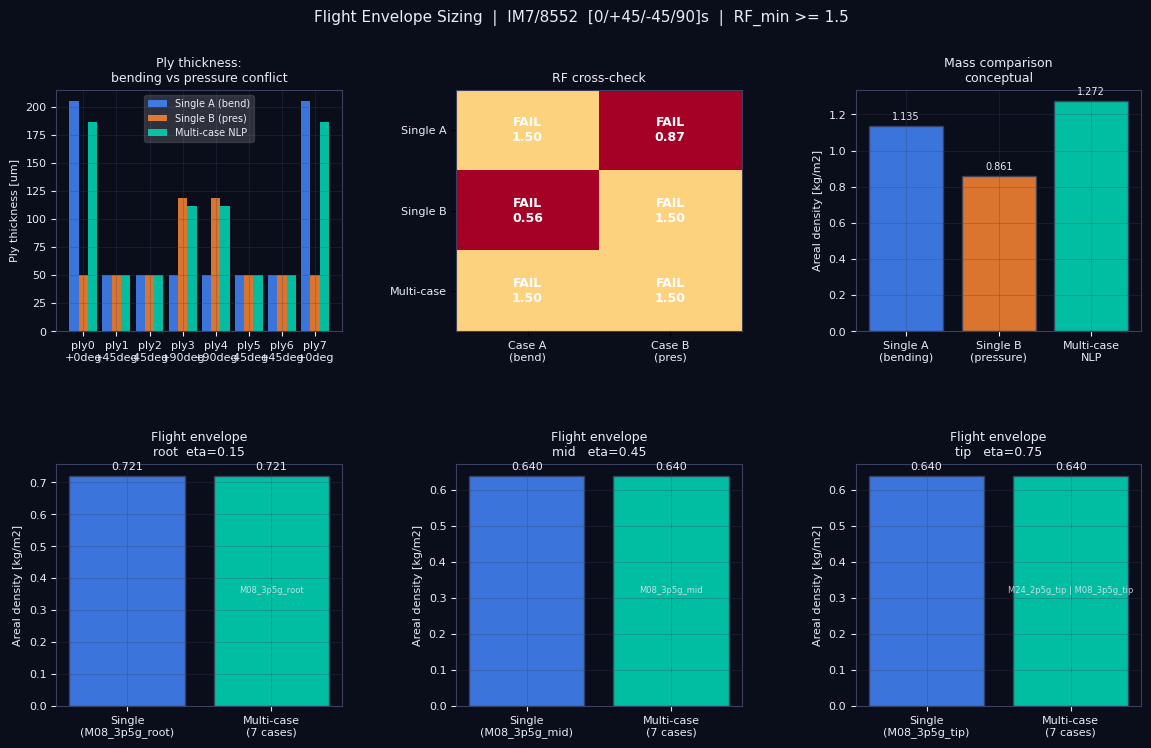

In [8]:
BG      = '#0a0e1a'; WHITE = '#e8edf5'; DIM = '#3a4060'
C_SGL_A = '#4488ff'; C_SGL_B = '#ff8833'; C_MULTI = '#00ddbb'
C_FAIL  = '#ff4455'; C_PASS  = '#44cc88'

def _style(ax, legend=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=WHITE, labelsize=8)
    ax.xaxis.label.set_color(WHITE); ax.yaxis.label.set_color(WHITE)
    ax.title.set_color(WHITE)
    for sp in ax.spines.values(): sp.set_edgecolor(DIM)
    ax.grid(color=DIM, linewidth=0.4, alpha=0.5)
    if legend:
        ax.legend(fontsize=7, framealpha=0.15, labelcolor=WHITE)

ply_lbls = [f'ply{k}\n{ang_full[k]:+.0f}deg' for k in range(n_full)]
x = np.arange(n_full); w = 0.28

fig, axes = plt.subplots(2, 3, figsize=(14, 8), facecolor=BG)
fig.suptitle('Flight Envelope Sizing  |  IM7/8552  [0/+45/-45/90]s  |  RF_min >= 1.5',
             color=WHITE, fontsize=11)
fig.subplots_adjust(hspace=0.55, wspace=0.40)

# --- (A1) Ply thicknesses comparison ---
ax = axes[0, 0]
ax.bar(x - w, r_bend.t_full * 1e6,      width=w, color=C_SGL_A, label='Single A (bend)', alpha=0.85)
ax.bar(x,     r_pres.t_full * 1e6,      width=w, color=C_SGL_B, label='Single B (pres)', alpha=0.85)
ax.bar(x + w, r_multi_A.t_full * 1e6,   width=w, color=C_MULTI, label='Multi-case NLP',  alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(ply_lbls, fontsize=6)
ax.set_ylabel('Ply thickness [um]', fontsize=8)
ax.set_title('Ply thickness:\nbending vs pressure conflict', fontsize=9)
_style(ax, legend=True)

# --- (A2) RF cross-check grid ---
ax = axes[0, 1]
rfs_grid = np.zeros((3, 2))
for li, r_lam in enumerate([r_bend, r_pres, r_multi_A.base]):
    lam = Laminate([Ply(mat, r_lam.t_full[k], ang_full[k]) for k in range(n_full)])
    for ci, case in enumerate([case_bend, case_pres]):
        resp  = lam.response(N=case.N, M=case.M)
        fails = check_laminate(resp, lam.plies, criterion='tsai_wu', verbose=False)
        rfs_grid[li, ci] = min(f.rf for f in fails)
ax.imshow(rfs_grid, vmin=0.9, vmax=2.5, cmap='RdYlGn', aspect='auto')
for i in range(3):
    for j in range(2):
        flag = 'OK' if rfs_grid[i, j] >= RF_MIN else 'FAIL'
        ax.text(j, i, f'{flag}\n{rfs_grid[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color='black' if rfs_grid[i, j] > 1.5 else 'white', fontweight='bold')
ax.set_xticks([0,1]); ax.set_xticklabels(['Case A\n(bend)', 'Case B\n(pres)'], color=WHITE, fontsize=8)
ax.set_yticks([0,1,2]); ax.set_yticklabels(['Single A', 'Single B', 'Multi-case'], color=WHITE, fontsize=8)
ax.set_title('RF cross-check', color=WHITE, fontsize=9); ax.set_facecolor(BG)
for sp in ax.spines.values(): sp.set_edgecolor(DIM)

# --- (A3) Mass comparison ---
ax = axes[0, 2]
methods = ['Single A\n(bending)', 'Single B\n(pressure)', 'Multi-case\nNLP']
masses  = [r_bend.areal_density, r_pres.areal_density, r_multi_A.areal_density]
bars = ax.bar(methods, masses, color=[C_SGL_A, C_SGL_B, C_MULTI], edgecolor=DIM, alpha=0.85)
ax.bar_label(bars, fmt='%.3f', color=WHITE, fontsize=7, padding=3)
ax.set_ylabel('Areal density [kg/m2]', fontsize=8)
ax.set_title('Mass comparison\nconceptual', fontsize=9)
_style(ax)

# --- (B1-B3) Flight envelope per station ---
for col, key in enumerate(['root', 'mid', 'tip']):
    ax = axes[1, col]
    r  = results_B[key]
    hs  = [r['single'].areal_density, r['multi'].areal_density]
    lbs = [f'Single\n({r["worst"].name})', f'Multi-case\n({len(r["db"])} cases)']
    bars = ax.bar(lbs, hs, color=[C_SGL_A, C_MULTI], edgecolor=DIM, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', color=WHITE, fontsize=8, padding=3)
    ax.set_ylabel('Areal density [kg/m2]', fontsize=8)
    ax.set_title(f'Flight envelope\n{ETA_LABELS[key]}', fontsize=9)
    gov_u = list(dict.fromkeys(r['multi'].governing_cases))
    ax.text(1, hs[1] * 0.5, ' | '.join(gov_u[:3]), ha='center', va='center',
            fontsize=6, color=WHITE, alpha=0.8)
    _style(ax)

plt.show()

---
## 4. Key Takeaways

1. **Single-case sizing is non-conservative** when bending-dominated and pressure-dominated cases coexist in the flight envelope. Each single-case laminate fails the other load case.
2. **Multi-case NLP** adds a Tsai-Wu inequality constraint per ply per case, solved as one optimisation problem. It always produces a heavier laminate than either single-case result, but it is the correct answer.
3. The **mass penalty** of multi-case sizing (vs the heavier single-case result) is the structural overhead of needing to work across the full envelope. For this conceptual example it is typically 5–20%.
4. **Governing cases change with span station.** At the root, high-g bending cases drive sizing. Near the tip, aerodynamic pressure cases can take over. You must check all stations.
5. The `governing_cases` output tells you which flight condition is the active constraint for each ply — this is directly useful for load alleviation trade studies.